##### Author: Jimin Kim (jk55@uw.edu)
##### Version 1.5.0

# Lab 5 Report

## Group Members:

In [189]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import dynworm as dw # MAKE SURE /dynworm FOLDER is INSIDE the same directory as this notebook file

In [190]:
from IPython.display import Image as ipyimage #For displaying images in colab jupyter cell

## Exercise 1: Visualize brain connectomes

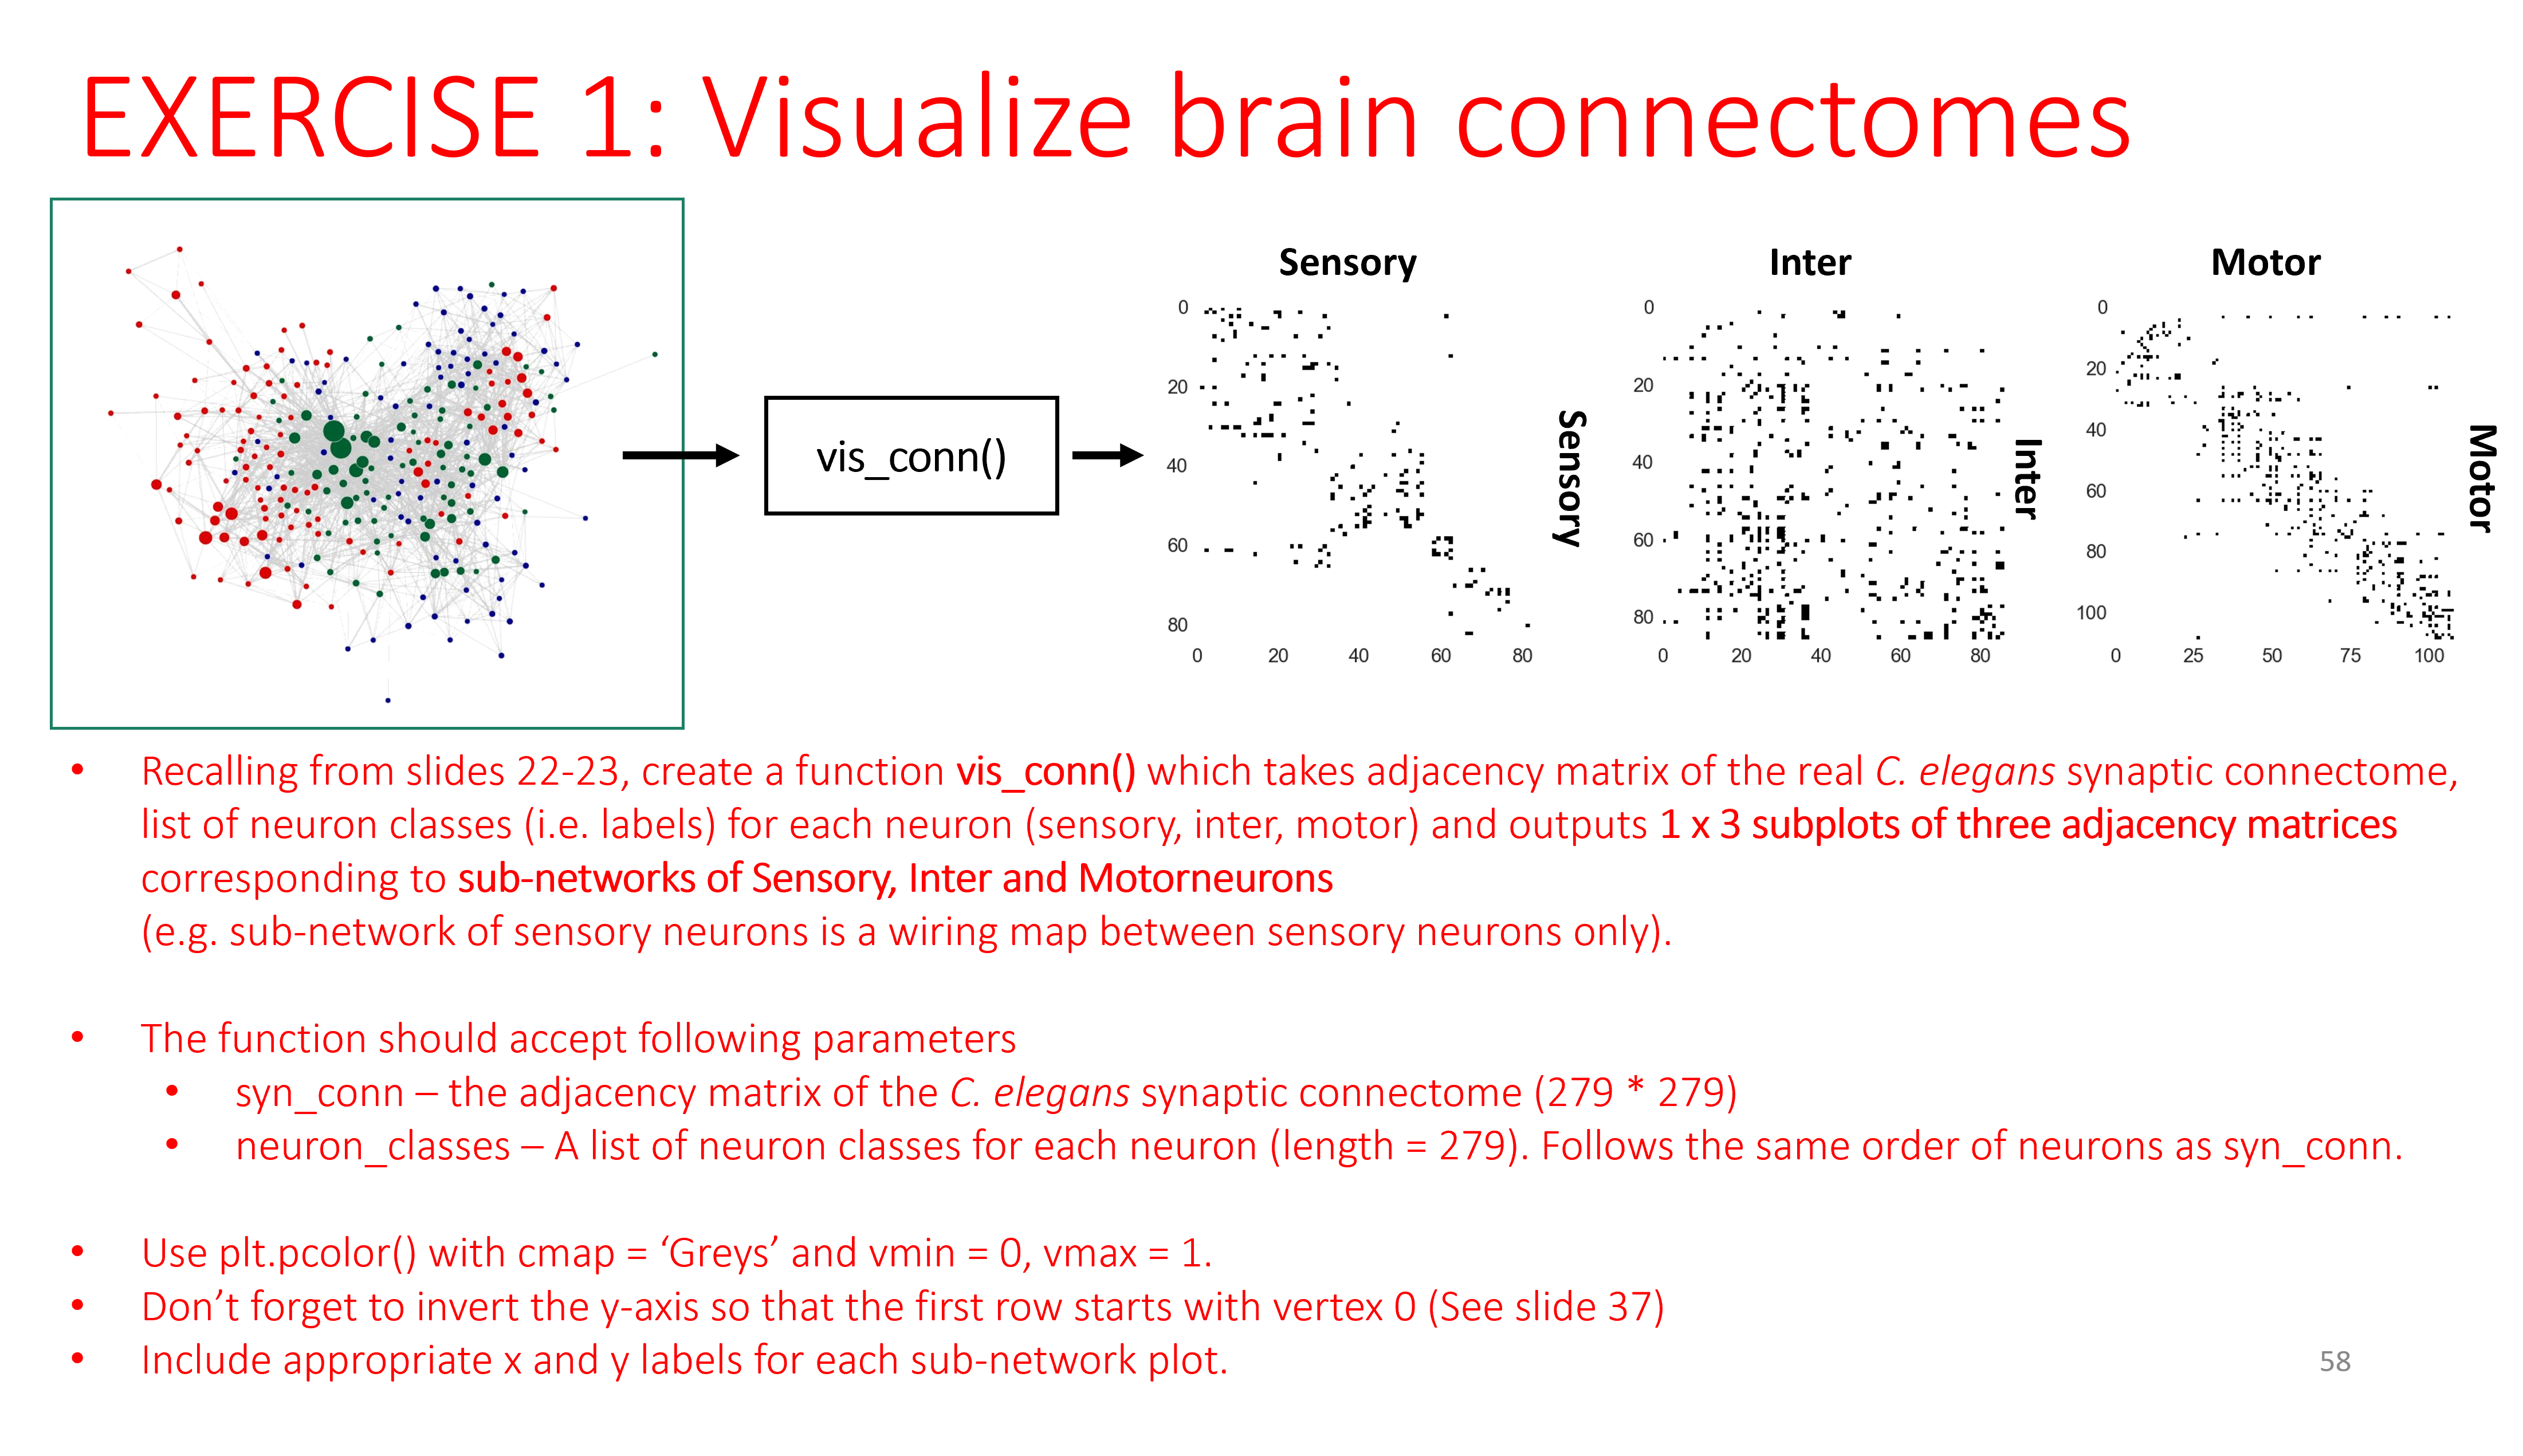

In [191]:
ipyimage('lab5_exercise1.PNG', width = 1000)

In [192]:
# Load synaptic connectome and neuron classes

celegans_syn_conn_pd = pd.read_excel('connectome_syn.xlsx')
celegans_syn_conn_np = np.array(celegans_syn_conn_pd)

# Classes are ordered according to the neurons' order in synaptic connectome
neuron_classes = np.load('neuron_classes.npy') 

In [193]:
# Adjacency matrix of the first 10 neurons
print(celegans_syn_conn_np[:10, :10])

[[0 0 0 3 0 0 7 0 0 0]
 [0 0 1 0 7 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 2 0 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 2 0 0 0 0 1]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


In [194]:
# Neuron classes of the first 10 neurons
print(neuron_classes[:10])

['sensory' 'sensory' 'sensory' 'sensory' 'sensory' 'sensory' 'sensory'
 'sensory' 'sensory' 'sensory']


In [195]:
def vis_conn(syn_conn, neuron_classes):
    """takes adjacency matrix of the real C. elegans synaptic connectome,
    list of neuron classes (i.e. labels) for each neuron (sensory, inter, motor) and outputs 1 x 3 subplots of three adjacency matrices
    corresponding to sub-networks of Sensory, Inter and Motorneurons

    Args:
        syn_conn (NDArray): the adjacency matrix of the C. elegans synaptic connectome (279 * 279)
        neuron_classes (List): A list of neuron classes for each neuron (length = 279). Follows the same order of neurons as syn_conn.
    """
    # Categories to plot
    groups = ['Sensory', 'Inter', 'Motor']
    
    # Create 1x3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, group in enumerate(groups):
        ax = axes[i]
        
        # 1. Get indices of neurons belonging to the current group
        # We assume the label contains the group name (e.g., 'Sensory' or 'Sensory Neuron')
        # We use case-insensitive matching to be robust
        indices = [idx for idx, label in enumerate(neuron_classes) if group.lower() in label.lower()]
        
        # 2. Extract the sub-network adjacency matrix
        # np.ix_ creates a mesh to extract the intersection of these rows and columns
        sub_network = syn_conn[np.ix_(indices, indices)]
        
        # 3. Plot 
        # vmin=0, vmax=1 ensures the colormap is fixed (White=0, Black=1 for 'Greys')
        # We wrap sub_network in np.array() to ensure it works if input was a matrix object
        pcm = ax.pcolor(np.array(sub_network), cmap='Greys', vmin=0, vmax=1, edgecolors='none')
        
        # 4. Invert Y-axis so row 0 is at the top (Matrix convention)
        ax.invert_yaxis()
        
        # 5. Labels and Titles
        ax.set_title(f'{group} - {group} Connectivity', fontsize=12)
        ax.set_xlabel(f'{group} Neuron Index (Target)')
        ax.set_ylabel(f'{group} Neuron Index (Source)')
        
        # Force aspect ratio to be square for better matrix visualization
        ax.set_aspect('equal')

    plt.suptitle('C. elegans Synaptic Connectome Sub-networks', fontsize=16)
    plt.tight_layout()
    plt.show()
    

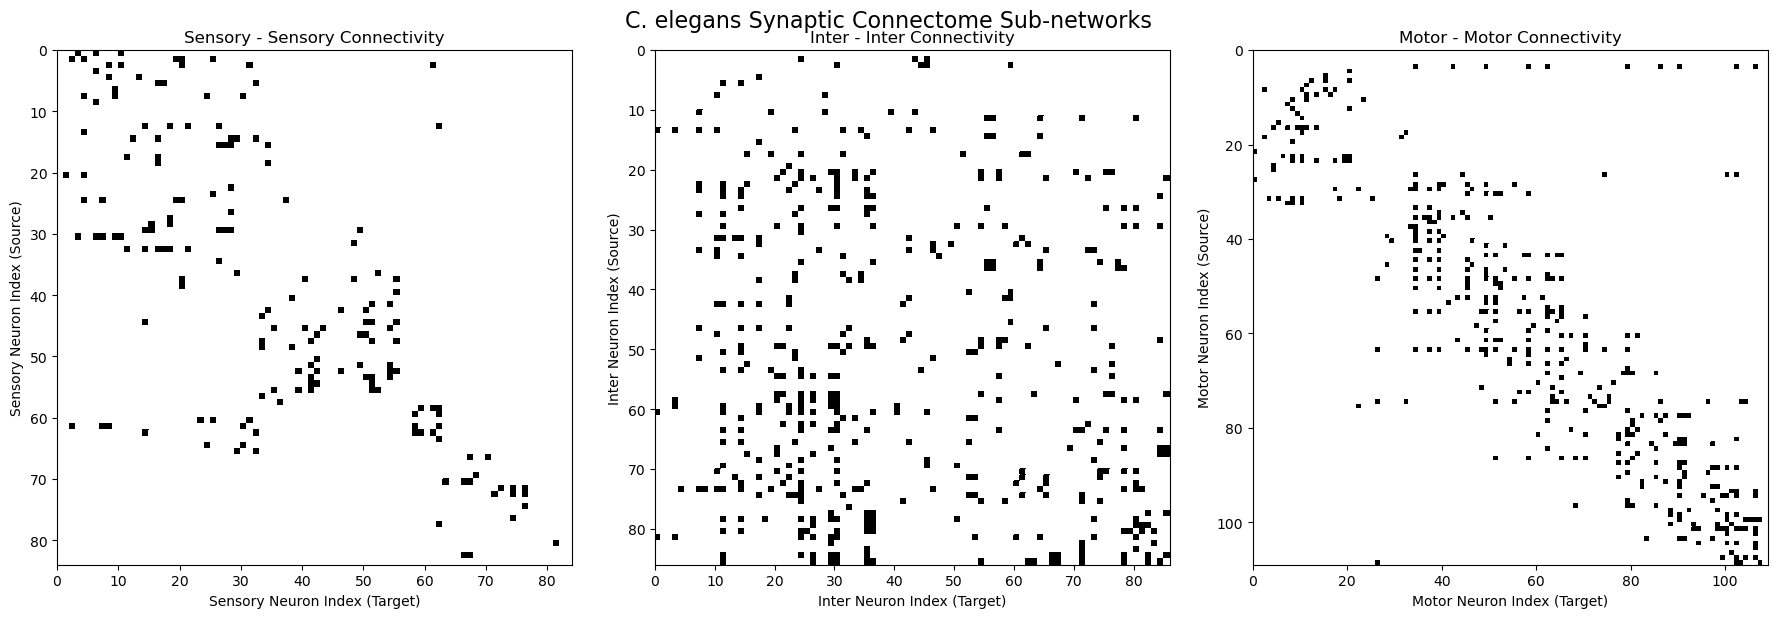

In [196]:
# Test your function here

vis_conn(syn_conn = celegans_syn_conn_np, neuron_classes = neuron_classes)

## Exercise 2: Locating the most connected vertices

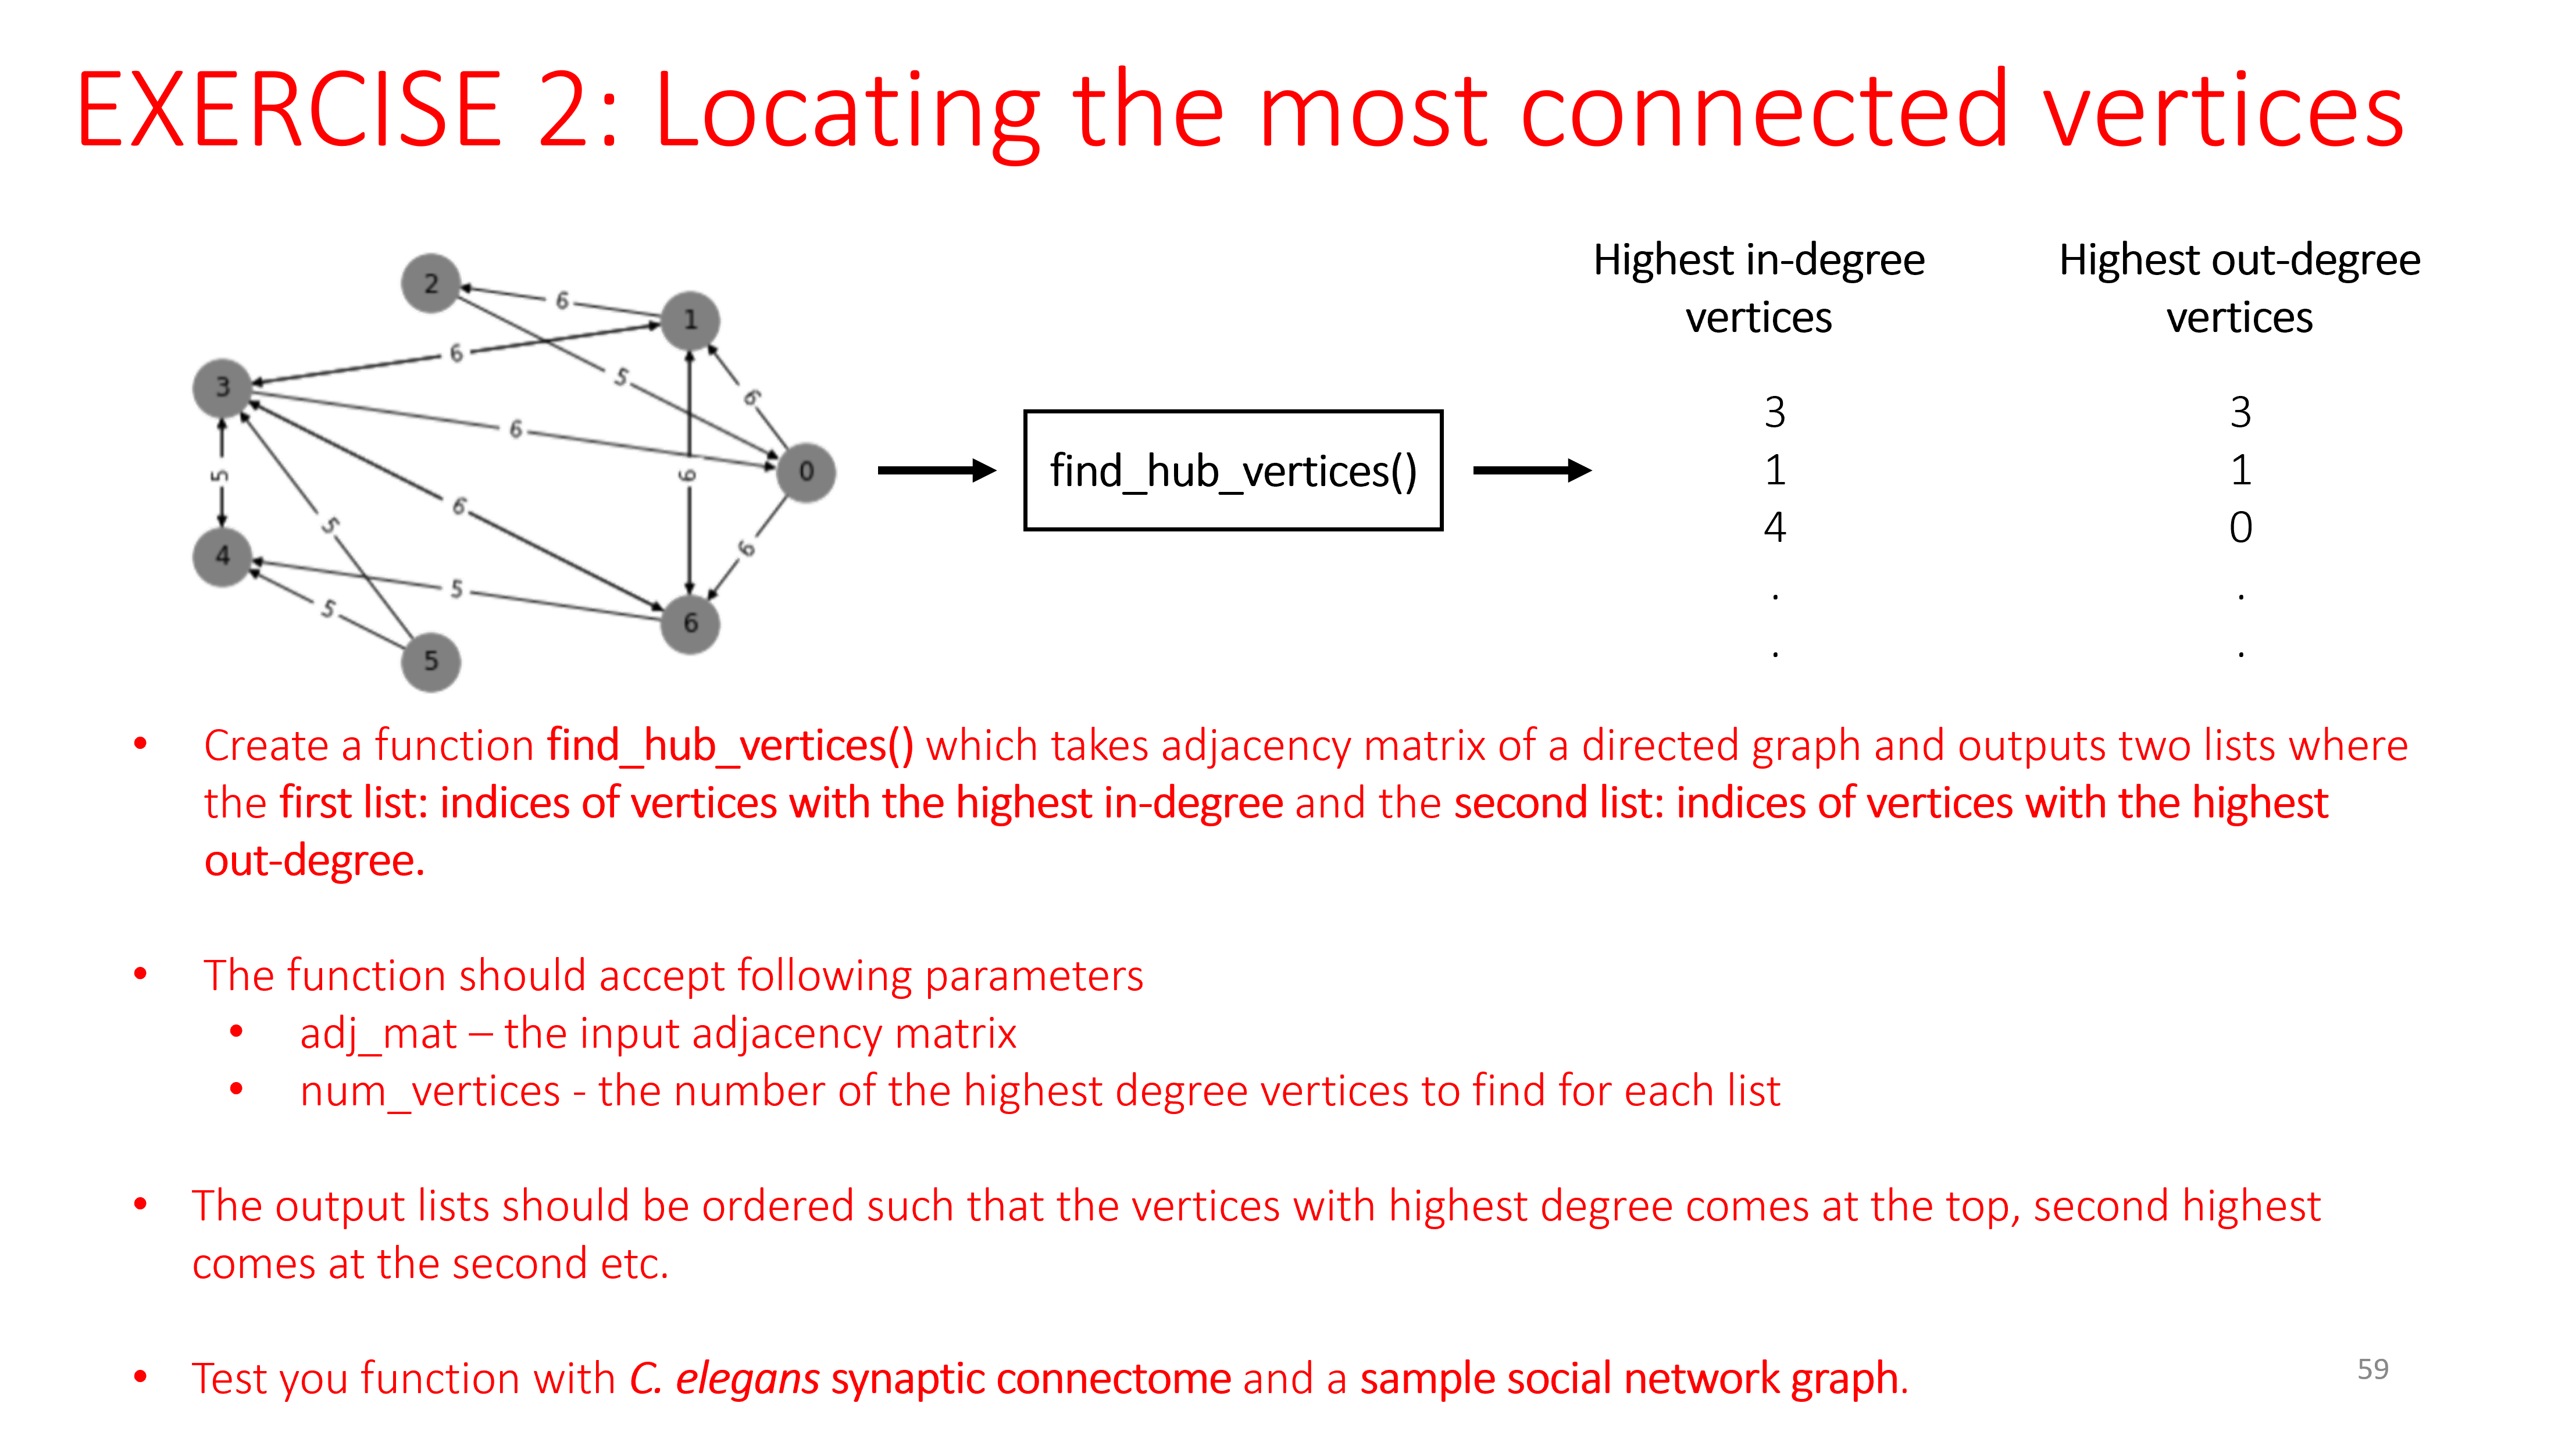

In [197]:
ipyimage('lab5_exercise2.PNG', width = 1000)

In [198]:
# Load the synaptic connectome and sample social network

syn_conn_pd = pd.read_excel('connectome_syn.xlsx')
syn_conn_np = np.array(syn_conn_pd)

social_network_sample_pd = pd.read_excel('social_network_sample.xlsx')
social_network_sample_np = np.array(social_network_sample_pd)

In [199]:
def find_hub_vertices(adj_mat, num_vertices):
    """ takes adjacency matrix of a directed graph and outputs two lists where
    the first list: indices of vertices with the highest in-degree and the second list: indices of vertices with the highest
    out-degree.

    Args:
        adj_mat (list or np.array): the input adjacency matrix (N x N)
        num_vertices (int): the number of the highest degree vertices to find for each list

    Returns:
        tuple: (indegree_list, outdegree_list) containing indices of top vertices
    """
    
    # Convert input to numpy array for efficient matrix operations
    matrix = np.array(adj_mat)
    
    # 1. Calculate Degrees
    # In a directed adjacency matrix (Row -> Col):
    # Summing over axis 0 (down the columns) gives In-degree (how many point TO this node)
    in_degree_counts = matrix.sum(axis=0)
    
    # Summing over axis 1 (across the rows) gives Out-degree (how many this node points TO)
    out_degree_counts = matrix.sum(axis=1)
    
    # 2. Get Indices Sorted by Degree (Descending)
    # np.argsort returns indices that would sort the array (ascending).
    # We use [::-1] to reverse it to descending order.
    sorted_in_indices = np.argsort(in_degree_counts)[::-1]
    sorted_out_indices = np.argsort(out_degree_counts)[::-1]
    
    # 3. Slice the top 'num_vertices'
    indegree_list = sorted_in_indices[:num_vertices].tolist()
    outdegree_list = sorted_out_indices[:num_vertices].tolist()
    
    return indegree_list, outdegree_list

In [200]:
# Test your function with synaptic connectome

indegree_list_syn_conn, outdegree_list_syn_conn = find_hub_vertices(adj_mat = syn_conn_np, num_vertices = 10)

In [201]:
print(indegree_list_syn_conn)

[105, 214, 195, 231, 48, 96, 181, 253, 58, 163]


In [202]:
print(outdegree_list_syn_conn)

[56, 48, 261, 64, 253, 267, 15, 7, 172, 244]


In [203]:
# Test your function with sample social media network

indegree_list_SN, outdegree_list_SN = find_hub_vertices(adj_mat = social_network_sample_np, num_vertices = 5)

In [204]:
print(indegree_list_SN)

[31, 62, 43, 93, 53]


In [205]:
print(outdegree_list_SN)

[1, 99, 26, 19, 49]


## Exercise 3: Removing vertices from a graph

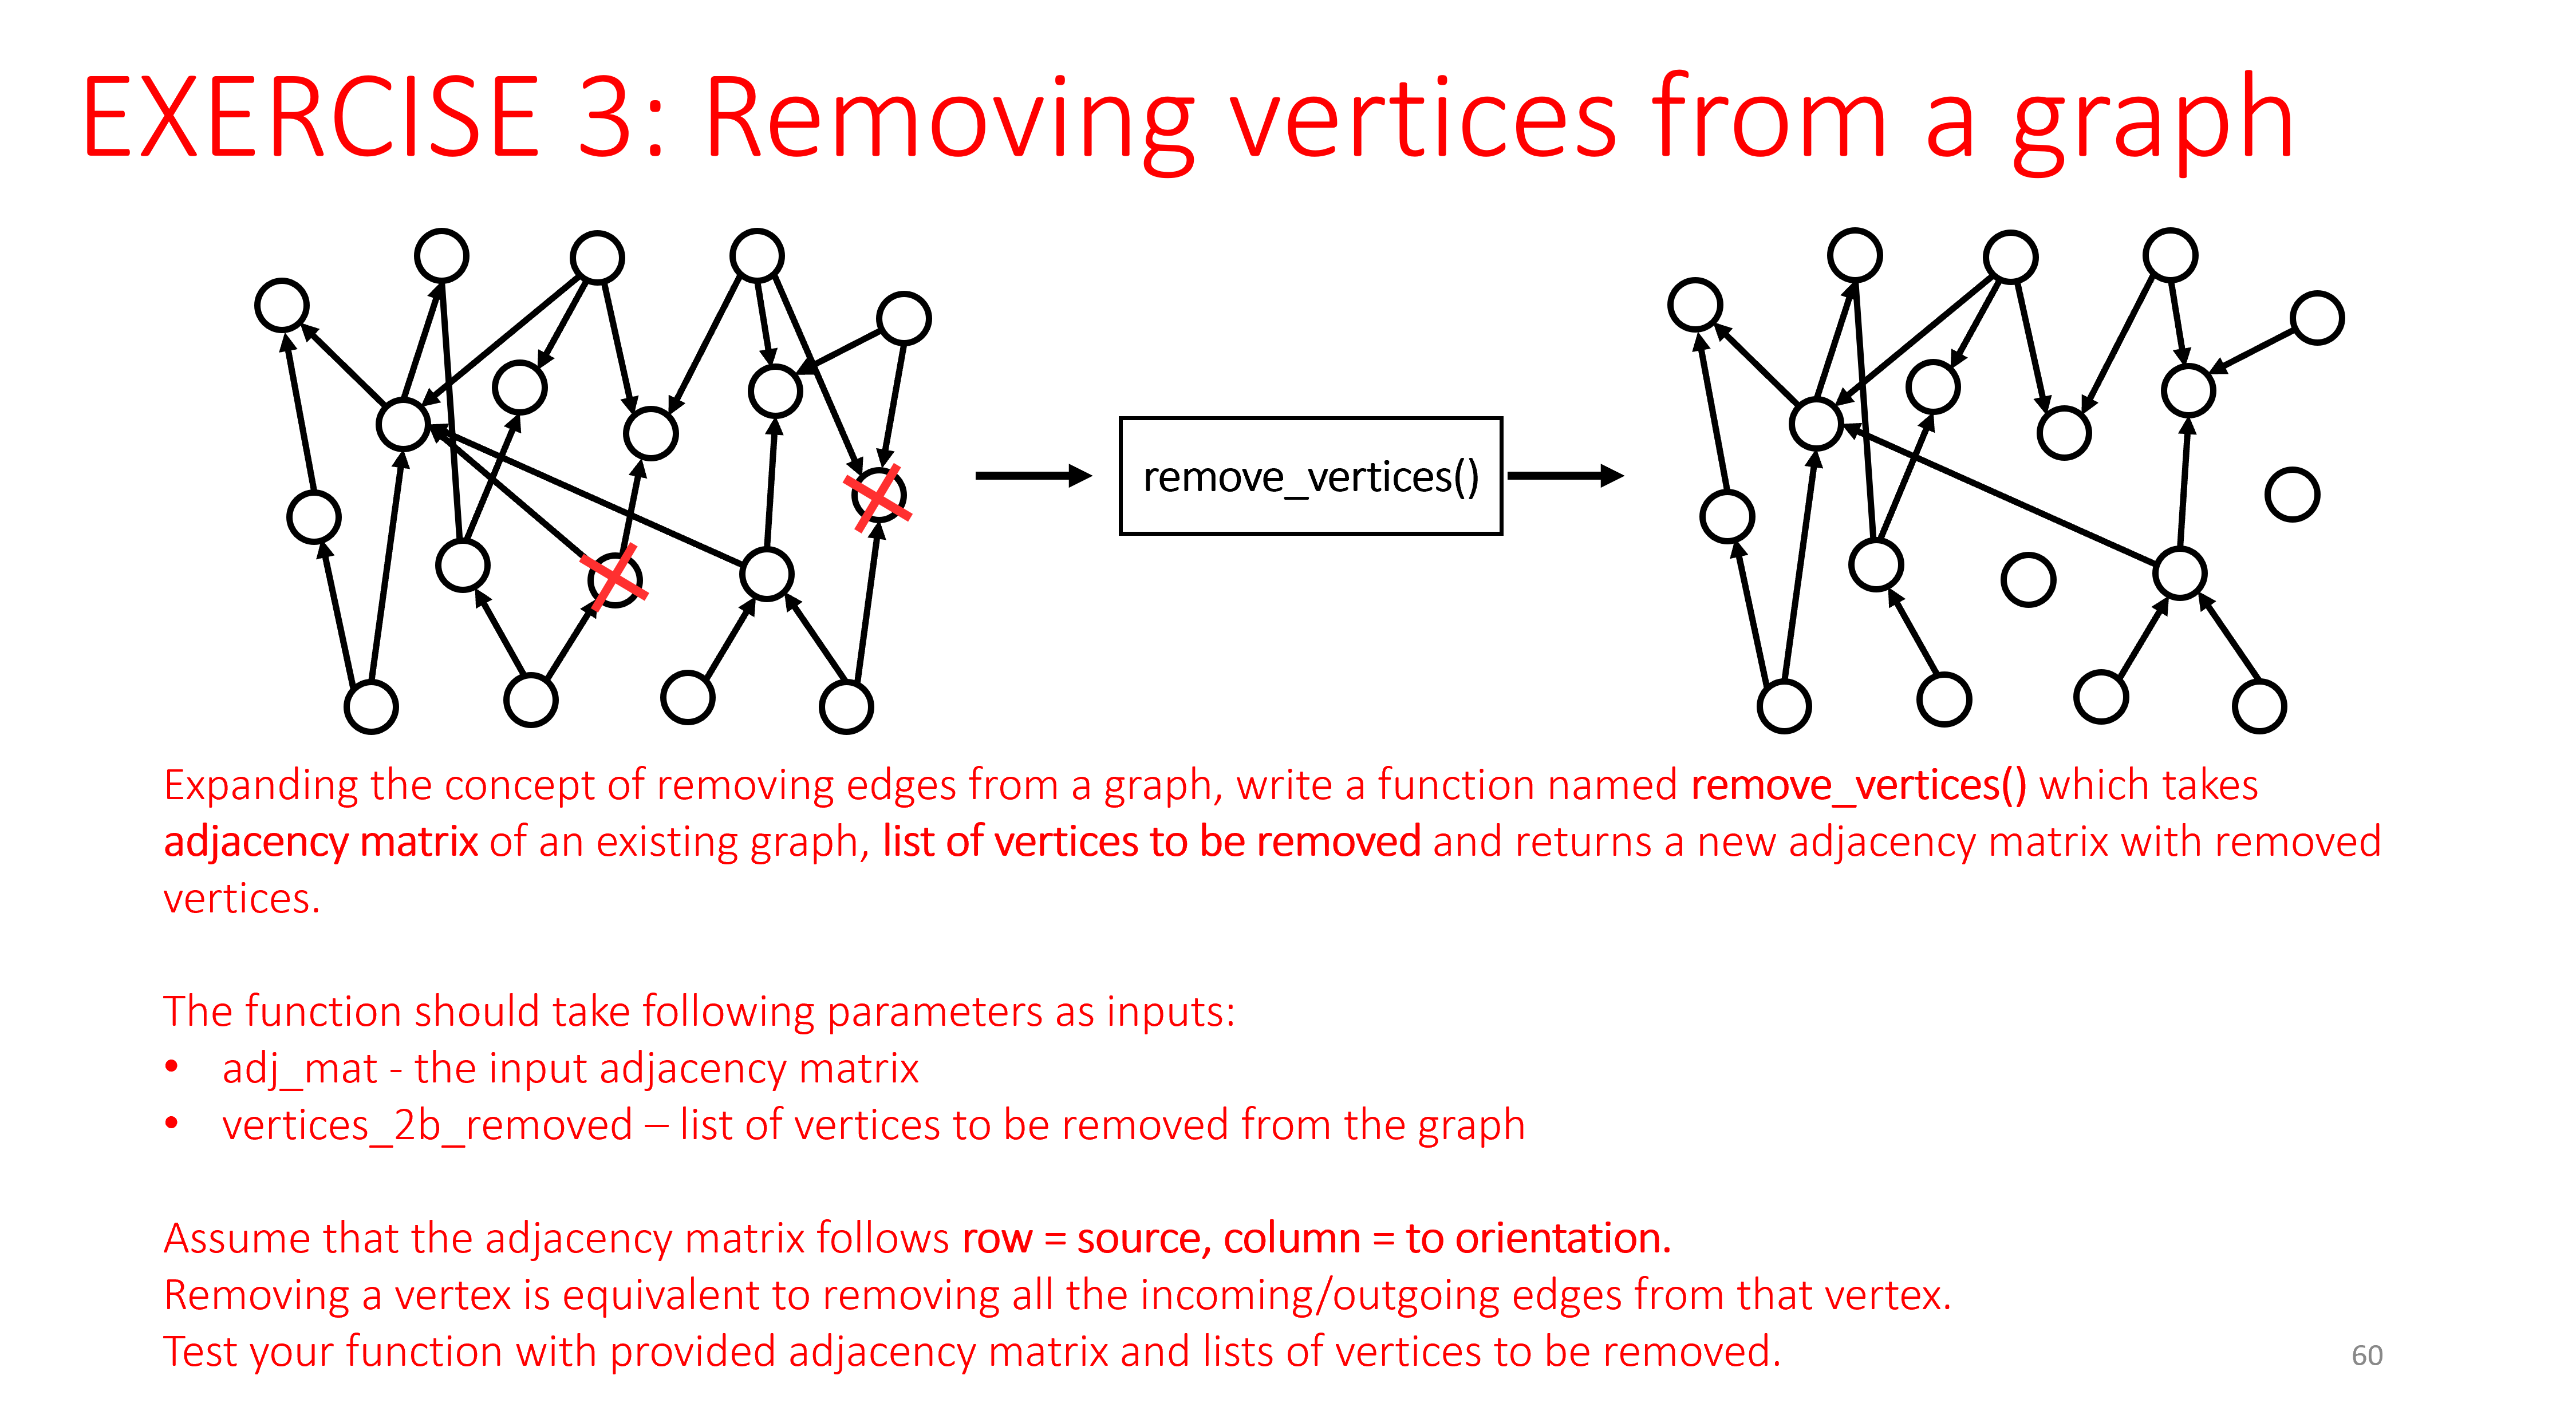

In [206]:
ipyimage('lab5_exercise3.PNG', width = 1000)

In [207]:
# We will use the pre-existing directed graph sample earlier in the lab

directed_adj_mat_pd = pd.read_excel('directed_sample.xlsx')
directed_adj_mat_np = np.array(directed_adj_mat_pd)

In [208]:
def remove_vertices(adj_mat, vertices_2b_removed):
    """
    Takes an adjacency matrix of an existing graph and a list of vertices to be removed, 
    and returns a new adjacency matrix with the specified vertices removed.

    Args:
        adj_mat (list of list of int): The input adjacency matrix (N x N).
        vertices_2b_removed (list of int): List of vertex indices to be removed.

    Returns:
        list of list of int: A new adjacency matrix with the rows and columns corresponding
                             to the removed vertices deleted.
    """
    
    # Get the total number of vertices in the current matrix
    num_vertices = len(adj_mat)
    
    # Convert the list to a set for faster O(1) lookups
    indices_to_remove = set(vertices_2b_removed)
    
    # Determine which indices we want to KEEP
    # We keep an index 'i' if it is NOT in the removal set
    kept_indices = [i for i in range(num_vertices) if i not in indices_to_remove]
    
    # Create the new matrix using a nested list comprehension.
    # We only include the row 'r' and column 'c' if both 'r' and 'c' are in our kept_indices list.
    adj_mat_new = [[adj_mat[r][c] for c in kept_indices] for r in kept_indices]
    
    return adj_mat_new

In [209]:
vertices_2b_removed_1 = [0, 5]        # Vertices to be removed set 1
vertices_2b_removed_2 = [1, 2, 6]     # Vertices to be removed set 2

In [210]:
# Test your function with set 1

directed_adj_mat_new_1 = remove_vertices(adj_mat = directed_adj_mat_np, vertices_2b_removed = vertices_2b_removed_1)
print(np.array(directed_adj_mat_new_1))

[[0 6 5 0 6]
 [0 0 0 0 0]
 [6 0 0 5 6]
 [0 0 5 0 0]
 [6 0 6 5 0]]


In [211]:
# Test your function with set 2

directed_adj_mat_new_2 = remove_vertices(adj_mat = directed_adj_mat_np, vertices_2b_removed = vertices_2b_removed_2)
print(np.array(directed_adj_mat_new_2))

[[0 0 0 0]
 [6 0 5 0]
 [0 5 0 0]
 [0 5 5 0]]


### Original graph image for reference

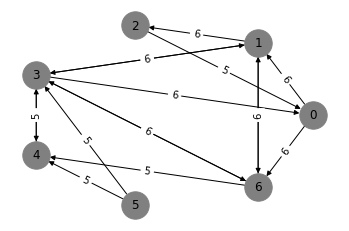

In [212]:
ipyimage('directed_sample_graph.PNG', width = 400)

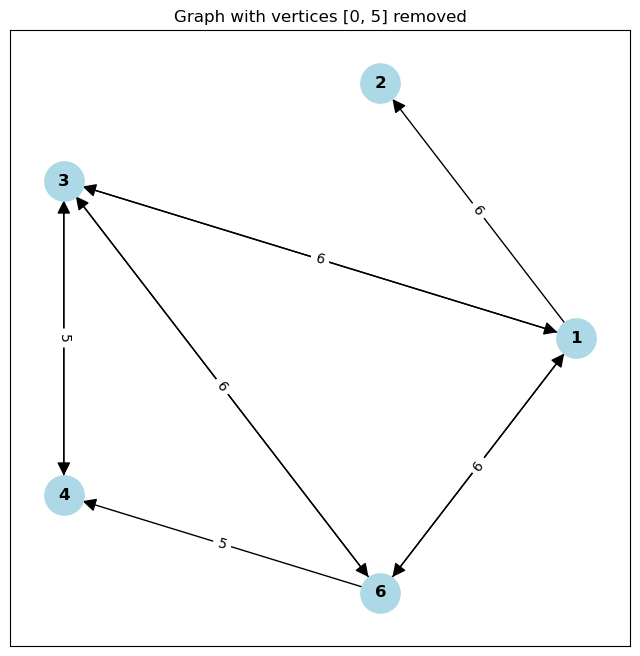

In [213]:
# Using networkX, plot your directed graph with removed vertices according to vertices_2b_removed_1

# 1. Create the Graph object from the new adjacency matrix
# We convert to np.array first as typical for nx.from_numpy_array
G1 = nx.from_numpy_array(np.array(directed_adj_mat_new_1), create_using=nx.DiGraph())

# 2. Relabel nodes to match original indices (optional but recommended for correctness)
# Calculate which indices were kept based on the original matrix size
num_original = len(directed_adj_mat_np)
kept_indices_1 = [i for i in range(num_original) if i not in vertices_2b_removed_1]
# Create a mapping from new index (0, 1, 2...) -> original index
mapping_1 = {new_idx: old_idx for new_idx, old_idx in enumerate(kept_indices_1)}
# Apply the mapping
G1 = nx.relabel_nodes(G1, mapping_1)

# 3. Setup Plot
plt.figure(figsize=(8, 8))
plt.title(f"Graph with vertices {vertices_2b_removed_1} removed")

# 4. Use circular graph layout
pos1 = nx.circular_layout(G1)

# 5. Draw the graph
nx.draw_networkx(G1, pos1, with_labels=True, node_color='lightblue', 
                 node_size=800, arrowsize=20, font_weight='bold')

# 6. Label your edges according to their weights
edge_labels1 = nx.get_edge_attributes(G1, 'weight')
nx.draw_networkx_edge_labels(G1, pos1, edge_labels=edge_labels1)

plt.show()

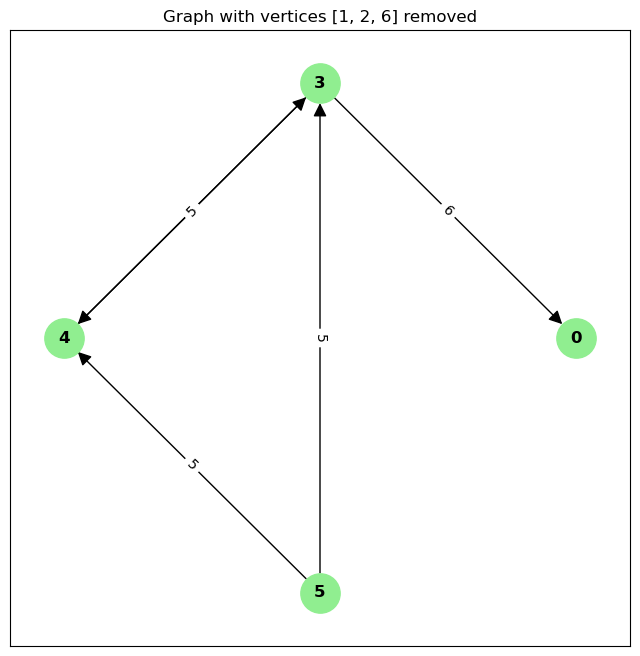

In [214]:
# Using networkX, plot your directed graph with removed vertices according to vertices_2b_removed_2

# 1. Create the Graph object
G2 = nx.from_numpy_array(np.array(directed_adj_mat_new_2), create_using=nx.DiGraph())

# 2. Relabel nodes
kept_indices_2 = [i for i in range(len(directed_adj_mat_np)) if i not in vertices_2b_removed_2]
mapping_2 = {new_idx: old_idx for new_idx, old_idx in enumerate(kept_indices_2)}
G2 = nx.relabel_nodes(G2, mapping_2)

# 3. Setup Plot
plt.figure(figsize=(8, 8))
plt.title(f"Graph with vertices {vertices_2b_removed_2} removed")

# 4. Use circular graph layout
pos2 = nx.circular_layout(G2)

# 5. Draw the graph
nx.draw_networkx(G2, pos2, with_labels=True, node_color='lightgreen', 
                 node_size=800, arrowsize=20, font_weight='bold')

# 6. Label your edges according to their weights
edge_labels2 = nx.get_edge_attributes(G2, 'weight')
nx.draw_networkx_edge_labels(G2, pos2, edge_labels=edge_labels2)

plt.show()

## Exercise 4: Adding a new vertex to a graph

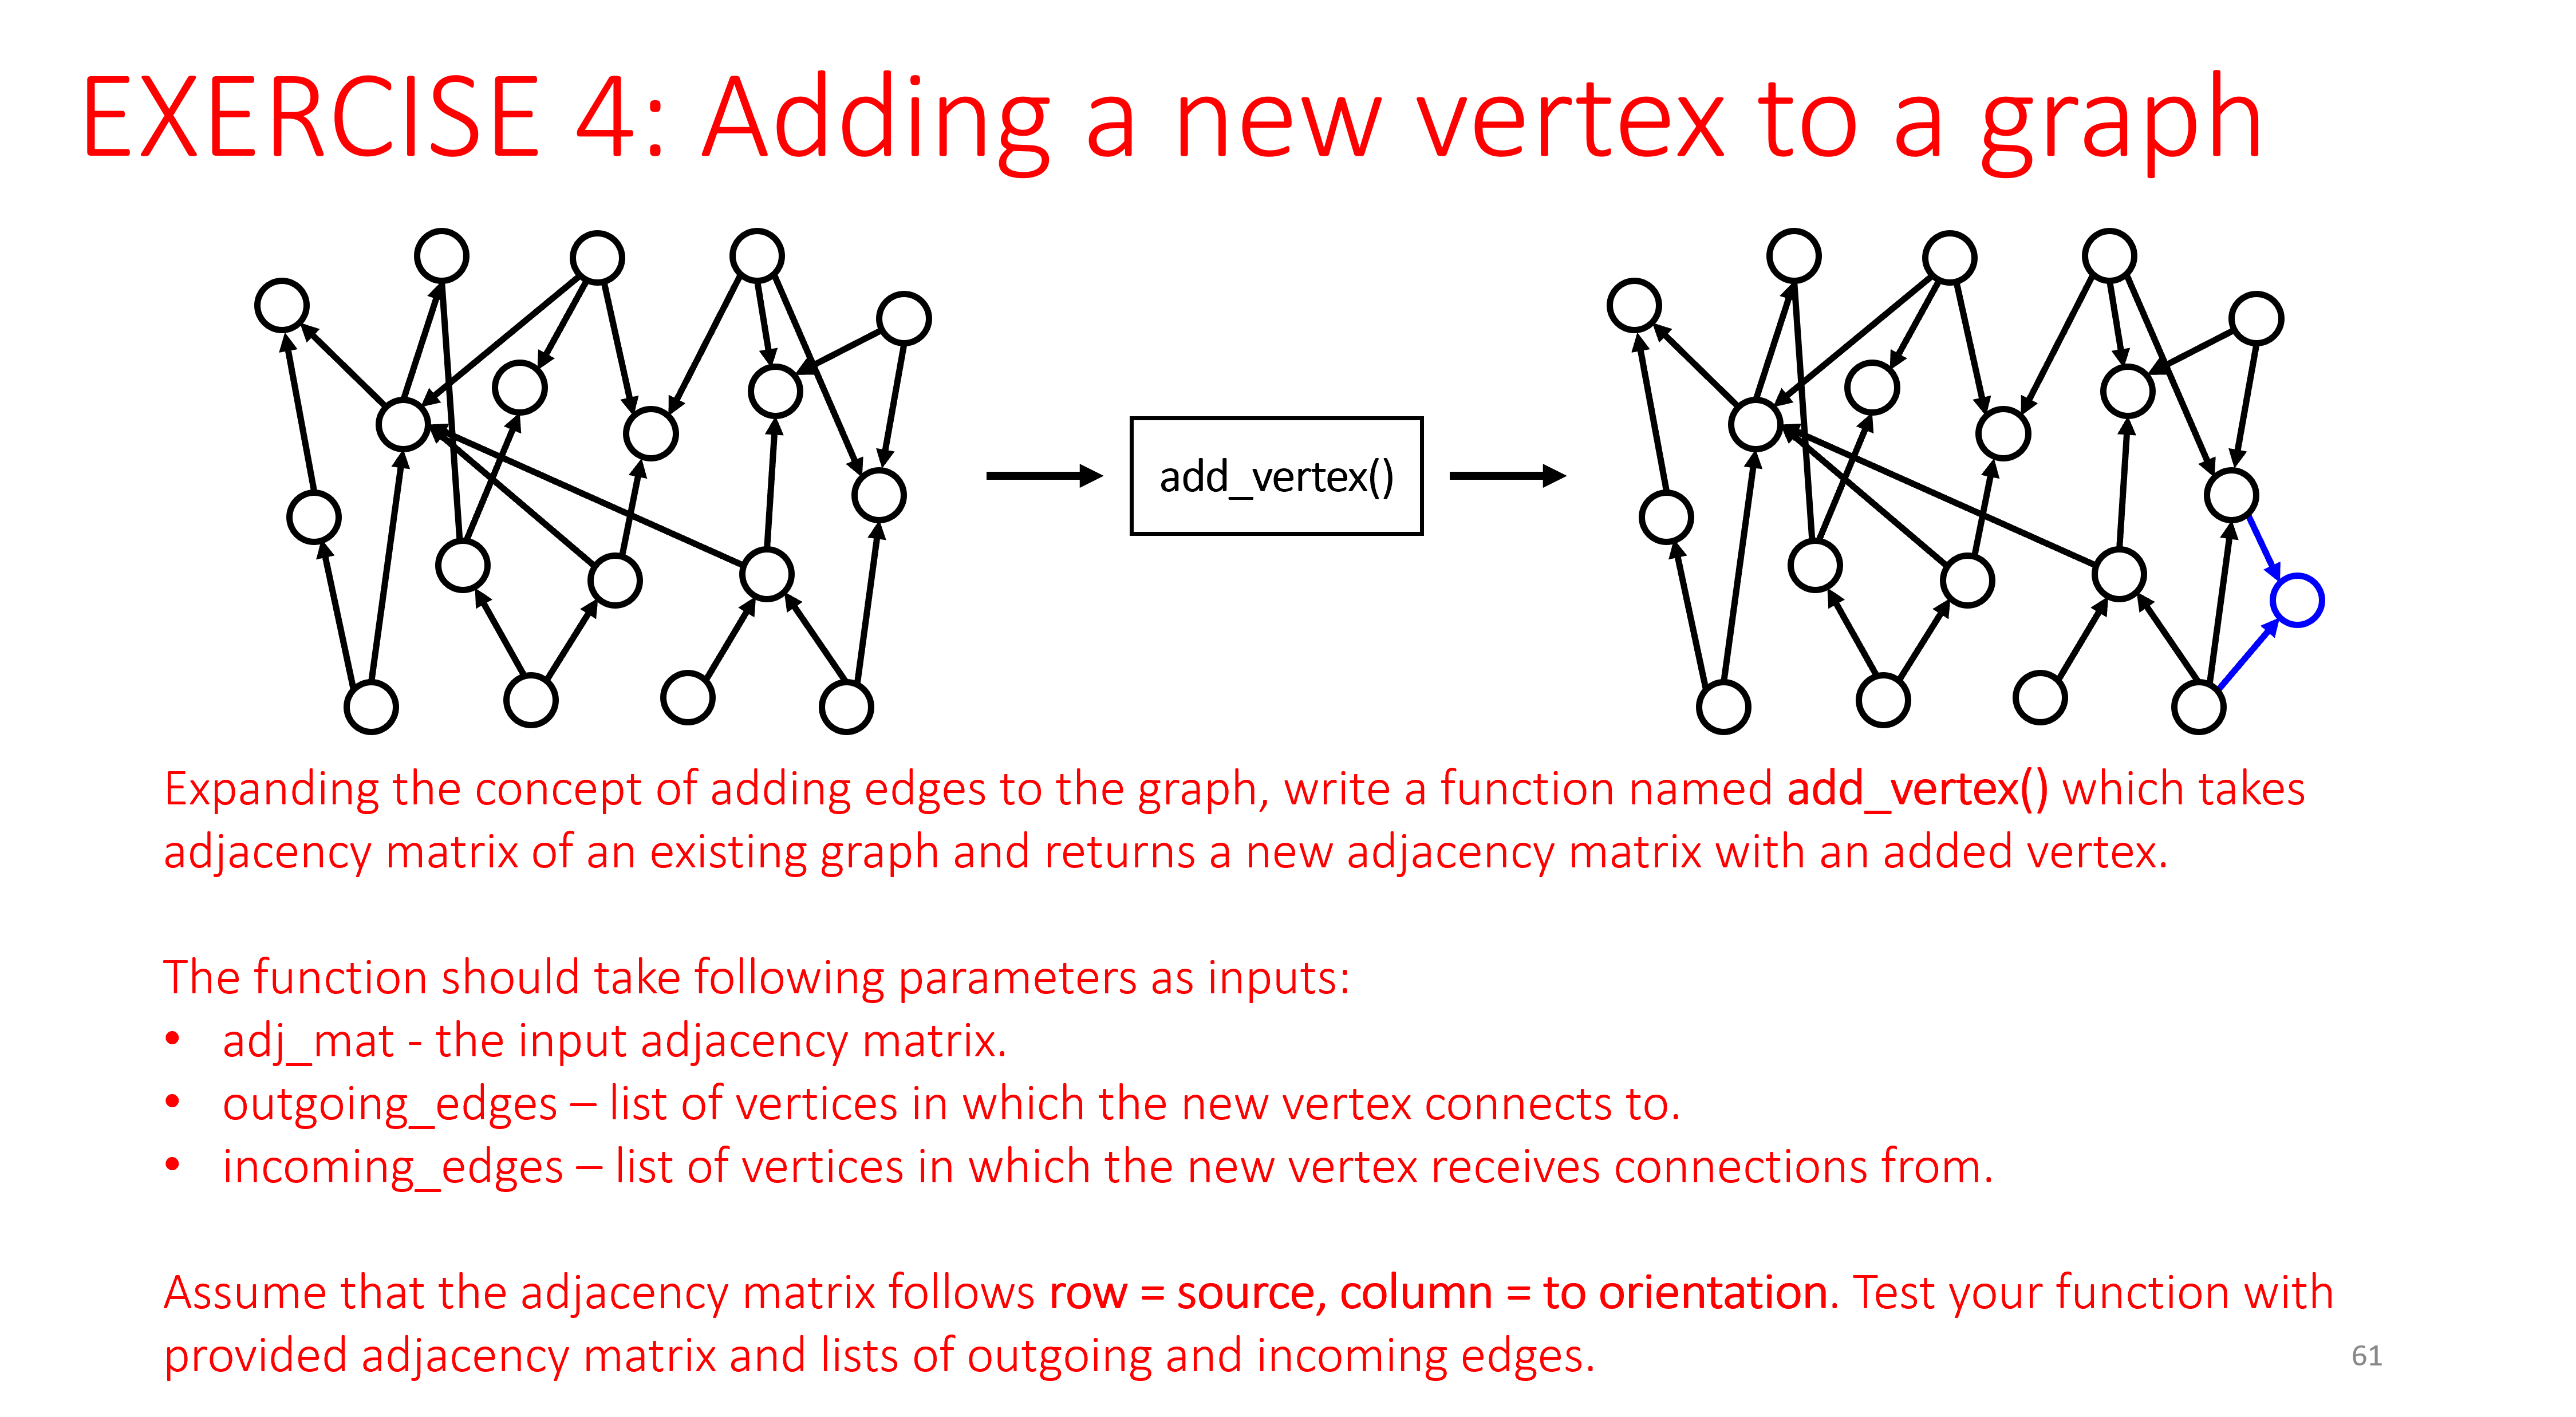

In [215]:
ipyimage('lab5_exercise4.PNG', width = 1000)

In [216]:
# We will use the pre-existing directed graph sample earlier in the lab
# The graph has 7 vertices

directed_adj_mat_pd = pd.read_excel('directed_sample.xlsx')
directed_adj_mat_np = np.array(directed_adj_mat_pd)

In [217]:
def add_vertex(adj_mat, outgoing_edges, incoming_edges):
    """
    Takes adjacency matrix of an existing graph and returns a new adjacency matrix with an added vertex.

    Args:
        adj_mat (list of list of int): the input adjacency matrix (N x N).
        outgoing_edges (list of int): list of vertices to which the new vertex connects.
        incoming_edges (list of int): list of vertices from which the new vertex receives connections.

    Returns:
        list of list of int: A new (N+1) x (N+1) adjacency matrix.
    """
    
    # Get the current number of vertices (N)
    n = len(adj_mat)
    
    # 1. Create a new (N+1) x (N+1) matrix initialized with zeros
    # We use n + 1 because we are adding 1 new vertex
    adj_mat_new = [[0] * (n + 1) for _ in range(n + 1)]
    
    # 2. Copy the existing data from the original matrix to the new matrix
    for r in range(n):
        for c in range(n):
            adj_mat_new[r][c] = adj_mat[r][c]
            
    # The index of the new vertex is 'n' (the last index in the new matrix)
    new_vertex_idx = n
    
    # 3. Handle Outgoing Edges: New Vertex -> Others
    # Row = Source (New Vertex), Column = Target
    # We set the weight to 1 as requested
    for target in outgoing_edges:
        if target < n:  # Ensure target exists in the original graph
            adj_mat_new[new_vertex_idx][target] = 1
            
    # 4. Handle Incoming Edges: Others -> New Vertex
    # Row = Source, Column = Target (New Vertex)
    for source in incoming_edges:
        if source < n:  # Ensure source exists in the original graph
            adj_mat_new[source][new_vertex_idx] = 1
    
    return adj_mat_new

In [218]:
# Define outgoing and incoming edges for the new vertex to be added

outgoing_edges = [2, 3, 5]
incoming_edges = [3, 4, 6]

In [219]:
# Test your function with provided list of outgoing/incoming edges

directed_adj_mat_vertex_added = add_vertex(adj_mat = directed_adj_mat_np, 
                                  outgoing_edges = outgoing_edges, 
                                  incoming_edges = incoming_edges)


### Original graph image for reference

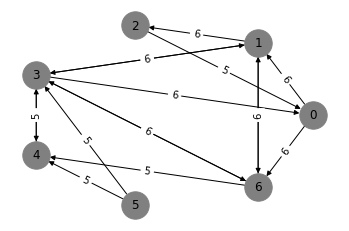

In [220]:
ipyimage('directed_sample_graph.PNG', width = 400)

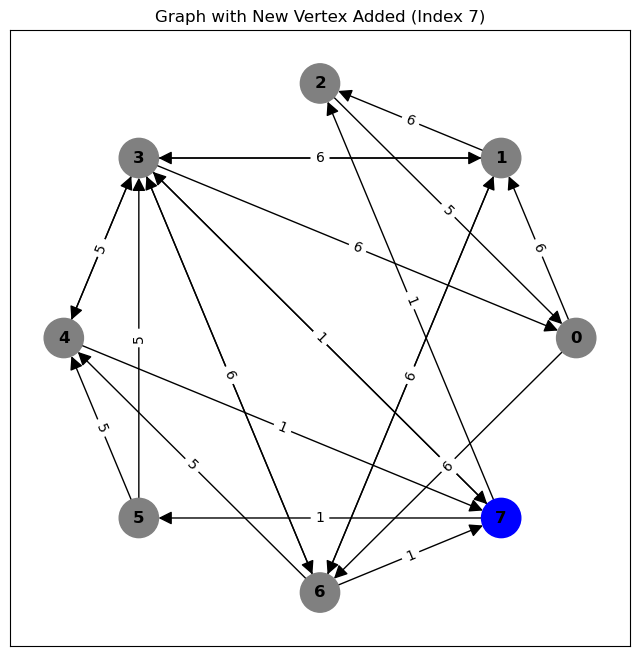

In [221]:
# Create the Graph object from the new adjacency matrix
# We convert the list of lists to a numpy array first for NetworkX
directed_graph_added = nx.from_numpy_array(np.array(directed_adj_mat_vertex_added), create_using=nx.DiGraph())

# Identify the index of the newly added vertex (it will be the last one)
new_vertex_index = len(directed_graph_added.nodes()) - 1

# Define node colors: Grey for original vertices, Blue for the new vertex
node_colors = ['grey' if node != new_vertex_index else 'blue' for node in directed_graph_added.nodes()]

plt.figure(figsize=(8, 8))
plt.title(f"Graph with New Vertex Added (Index {new_vertex_index})")

# Use circular graph layout
pos_added = nx.circular_layout(directed_graph_added)

# Draw the graph (nodes and edges)
nx.draw_networkx(directed_graph_added, pos_added, 
                 with_labels=True, 
                 node_color=node_colors, 
                 node_size=800, 
                 font_weight='bold', 
                 arrowsize=20)

# Label your edges according to their weights
edge_labels_added = nx.get_edge_attributes(directed_graph_added, 'weight')
nx.draw_networkx_edge_labels(directed_graph_added, pos_added, edge_labels=edge_labels_added)

plt.show()

## Exercise 5: Re-wire neurons to restore behavior of C. elegans

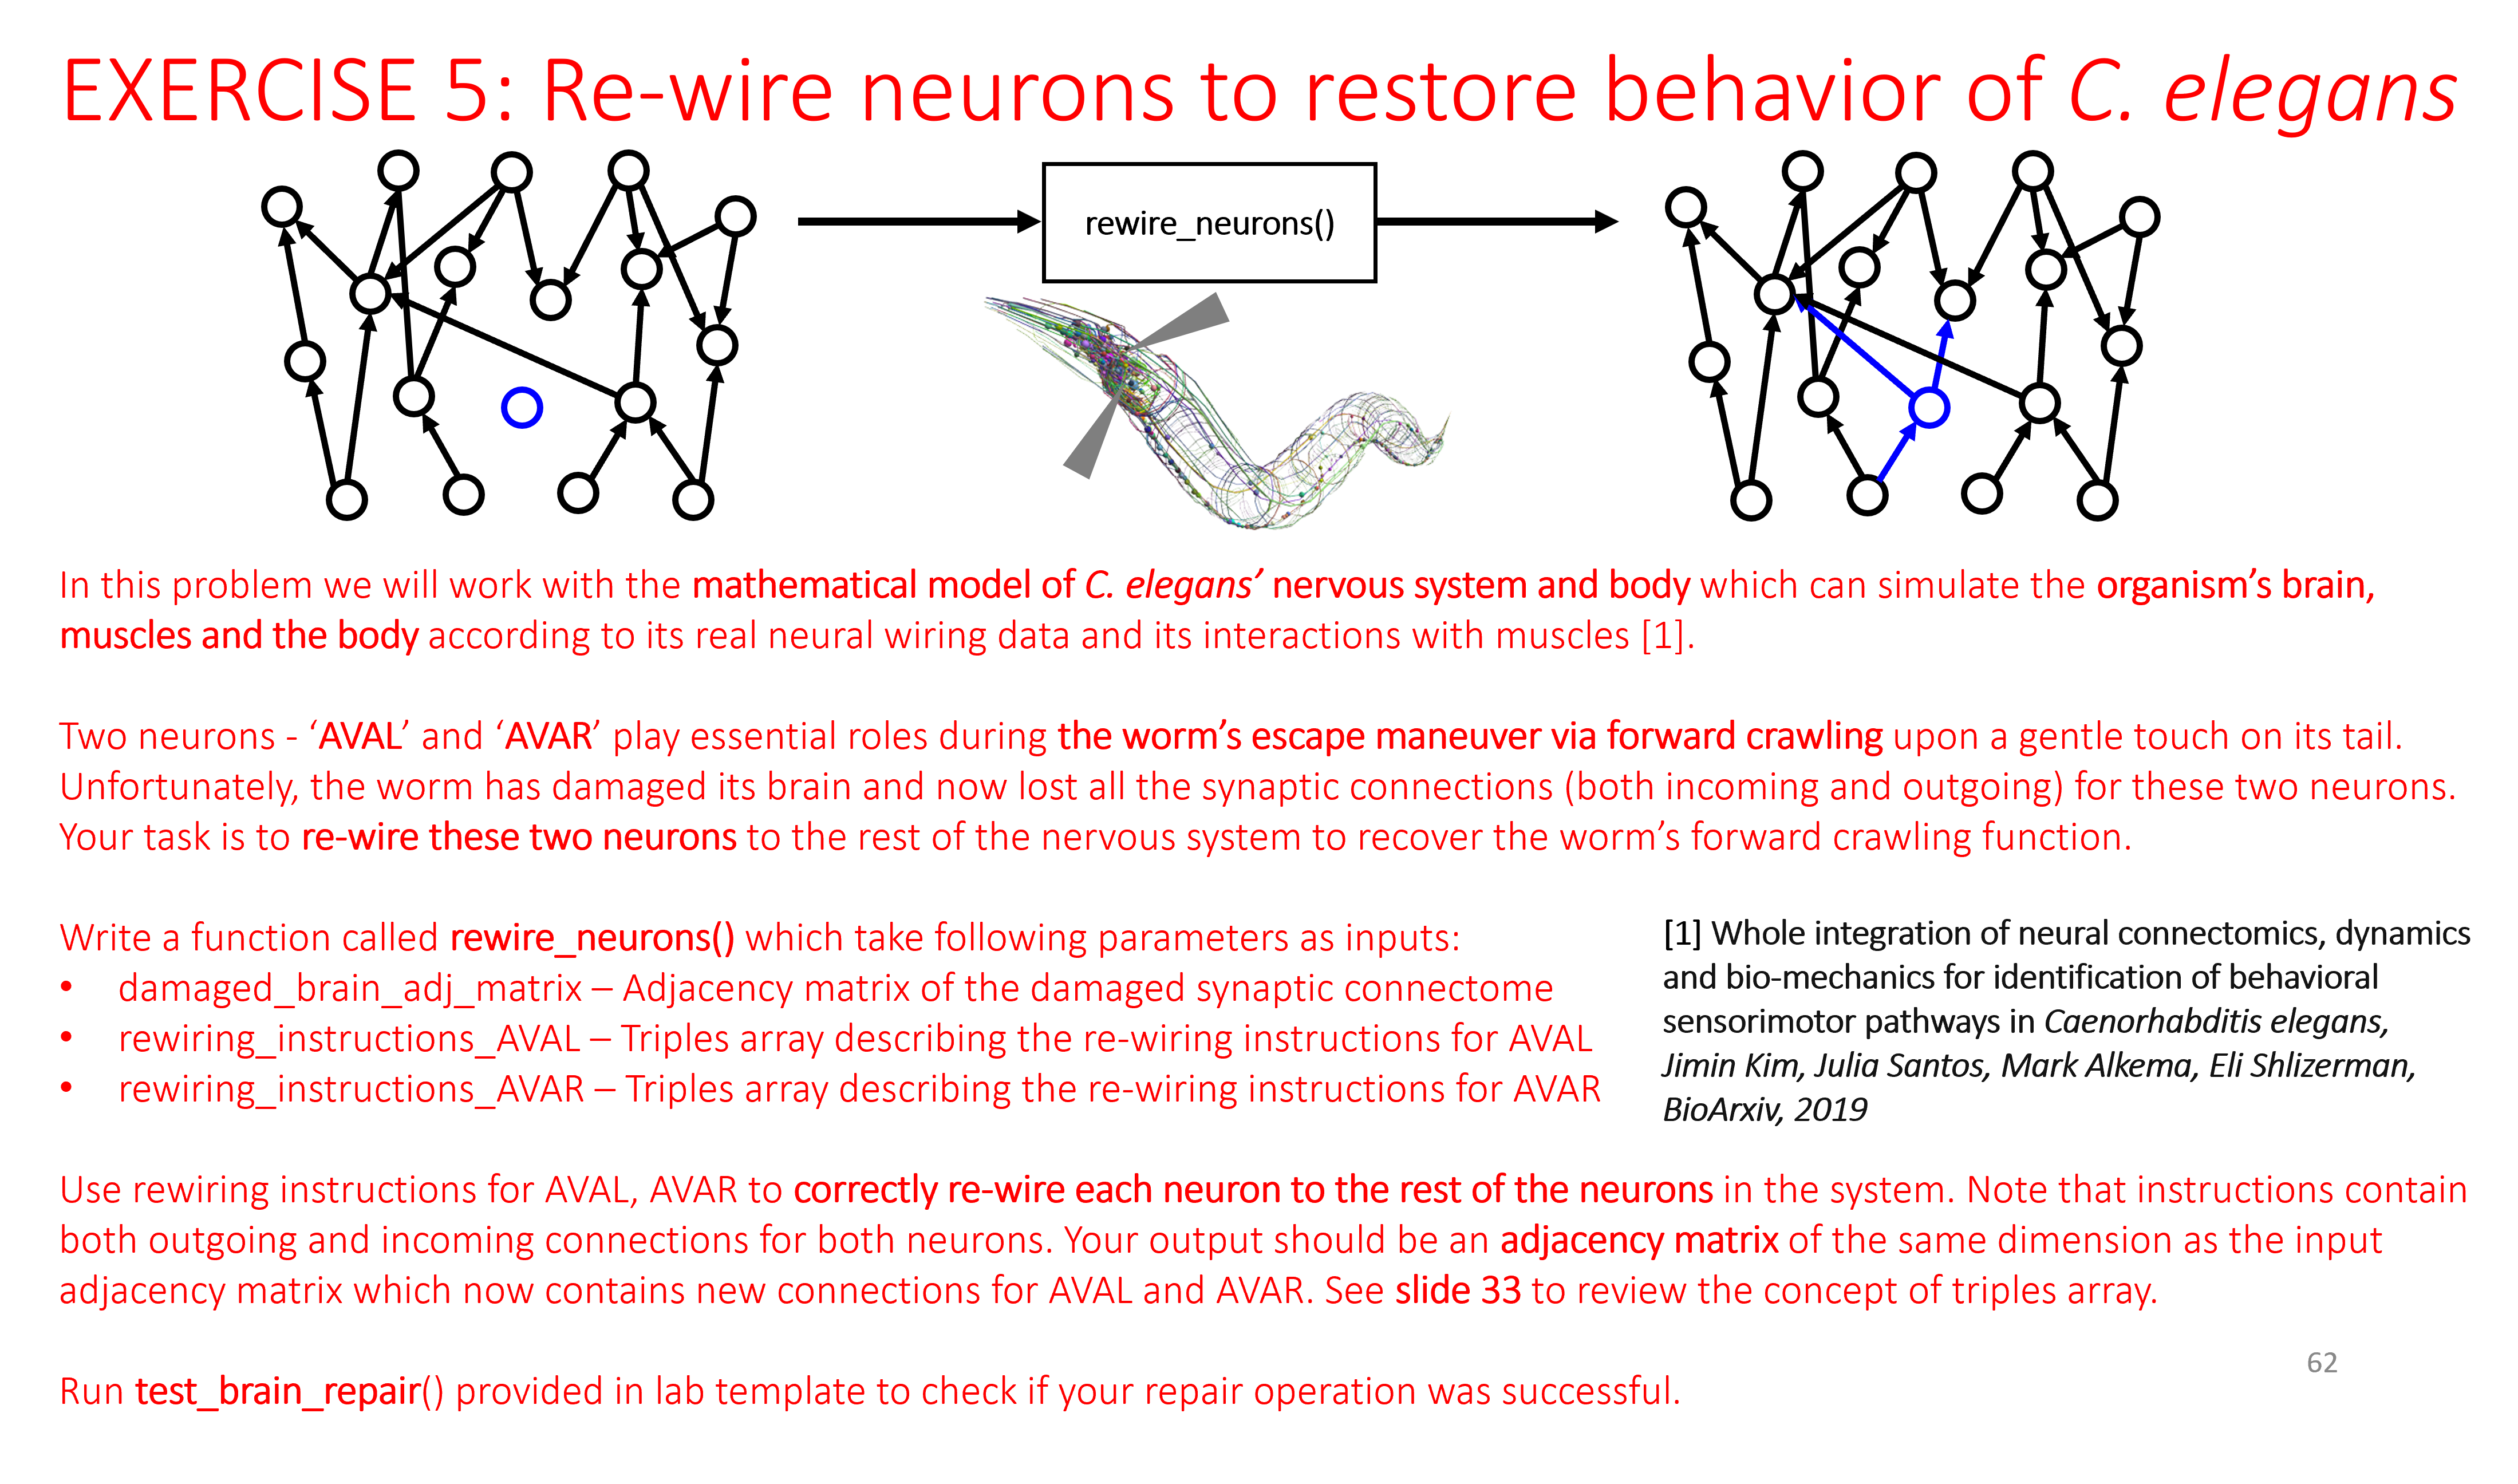

In [222]:
ipyimage('lab5_exercise5.PNG', width = 1000)

### Note: If you wish to use the included C. elegans simulation code in lab template folder outside of EE 241 (e.g. research purpose), please cite the following paper 
### Kim, J., Leahy, W., & Shlizerman, E. (2019). Neural interactome: Interactive simulation of a neuronal system. Frontiers in Computational Neuroscience, 13, 8. 

In [223]:
# Load synaptic connectome and neuron classes

damaged_syn_conn_pd = pd.read_excel('connectome_syn.xlsx')
damaged_syn_conn_np = np.array(damaged_syn_conn_pd)

## Motorneurons' activities during gentle tail touch (Damaged brain)

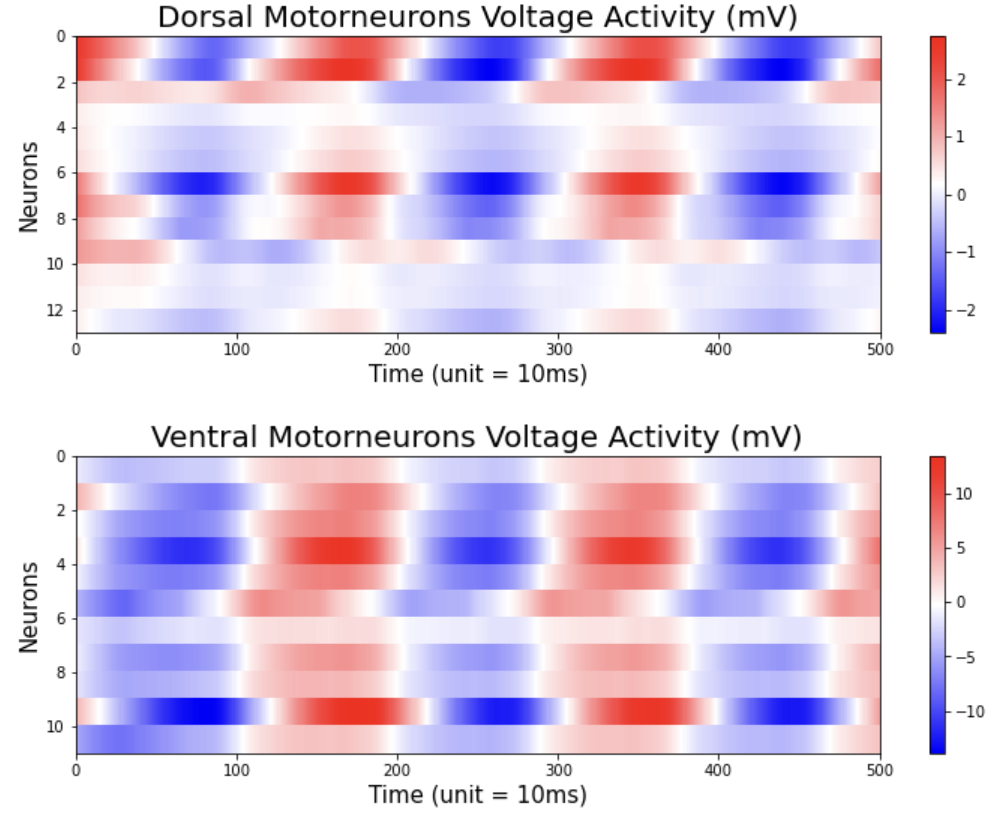

In [224]:
ipyimage('damaged_AVA_motor_activities.PNG', width = 450)

## Simulated body movement during gentle tail touch (Damaged brain)

In [225]:
from ipywidgets import Video

Video.from_file("escape_response_damaged.mp4", width=500, height=500)

Video(value=b'\x00\x00\x00 ftypisom\x00\x00\x02\x00isomiso2avc1mp41\x00\x00\x00\x08free\x00\x06\x01umdat\x00\x…

In [226]:
# Re-wiring instructions for AVAL and AVAR neurons

outgoing_AVAL_triples = np.load('AVAL_outgoing_triples.npy') # AVAL is the 47th vertex in the graph
incoming_AVAL_triples = np.load('AVAL_incoming_triples.npy') # AVAL is the 47th vertex in the graph

outgoing_AVAR_triples = np.load('AVAR_outgoing_triples.npy') # AVAR is the 55th vertex in the graph
incoming_AVAR_triples = np.load('AVAR_incoming_triples.npy') # AVAR is the 55th vertex in the graph

# Each row in the triple is ordered as [Source neuron index, Target neuron index, Synaptic weight]

rewiring_triples_AVAL = [outgoing_AVAL_triples, incoming_AVAL_triples]
rewiring_triples_AVAR = [outgoing_AVAR_triples, incoming_AVAR_triples]

In [ ]:
def rewire_neurons(damaged_synaptic_adj_matrix, rewiring_instructions_AVAL, rewiring_instructions_AVAR):
    """
    Rewire the damaged synaptic adjacency matrix according to the rewiring instructions for AVAL and AVAR neurons.
    Args:
        damaged_synaptic_adj_matrix: 2D numpy array, damaged synaptic adjacency matrix
        rewiring_instructions_AVAL: list of 2D numpy arrays, rewiring instructions for AVAL neuron (outgoing and incoming triples)
        rewiring_instructions_AVAR: list of 2D numpy arrays, rewiring instructions for AVAR neuron (outgoing and incoming triples)
    Returns:
        repaired_synaptic_adj_matrix: 2D numpy array, repaired synaptic adjacency matrix after rewiring
    """
    
    # 1. Create a copy of the damaged matrix
    repaired_synaptic_adj_matrix = np.array(damaged_synaptic_adj_matrix).copy()

    # ==============================
    # PROCESS AVAL
    # The input is likely a list of two arrays (incoming and outgoing).
    # np.vstack concatenates them into a single (N, 3) matrix.
    try:
        instr_AVAL = np.vstack(rewiring_instructions_AVAL)
    except:
        # Fallback: if it's already a clean list of lists, np.array works
        instr_AVAL = np.array(rewiring_instructions_AVAL)
        
    # Safety check: Remove extra dimensions if shape is (1, N, 3)
    if instr_AVAL.ndim == 3:
        instr_AVAL = instr_AVAL[0]
        
    # Extract columns: Source (col 0), Target (col 1), Weight (col 2)
    sources_AVAL = instr_AVAL[:, 0].astype(int)
    targets_AVAL = instr_AVAL[:, 1].astype(int)
    weights_AVAL = instr_AVAL[:, 2].astype(int)
    
    # Update the matrix
    repaired_synaptic_adj_matrix[sources_AVAL, targets_AVAL] = weights_AVAL

    # ==============================
    # PROCESS AVAR
    # The input is likely a list of two arrays (incoming and outgoing). 
    try:
        instr_AVAR = np.vstack(rewiring_instructions_AVAR)
    except:
        instr_AVAR = np.array(rewiring_instructions_AVAR)
        
    if instr_AVAR.ndim == 3:
        instr_AVAR = instr_AVAR[0]
        
    sources_AVAR = instr_AVAR[:, 0].astype(int)
    targets_AVAR = instr_AVAR[:, 1].astype(int)
    weights_AVAR = instr_AVAR[:, 2].astype(int)
    
    # Update the matrix
    repaired_synaptic_adj_matrix[sources_AVAR, targets_AVAR] = weights_AVAR
    
    return repaired_synaptic_adj_matrix

In [240]:
repaired_synaptic_adj_matrix = rewire_neurons(damaged_synaptic_adj_matrix = damaged_syn_conn_np, 
                                              rewiring_instructions_AVAL = rewiring_triples_AVAL, 
                                              rewiring_instructions_AVAR = rewiring_triples_AVAR)

Repair operation successful! - Simulating the nervous system and body for gentle tale touch
All neurons are healthy
Network integration prep completed...
Computing network dynamics...
11.1% completed
22.2% completed
33.3% completed
44.4% completed
55.5% completed
66.6% completed
77.7% completed
88.9% completed
100.0% completed


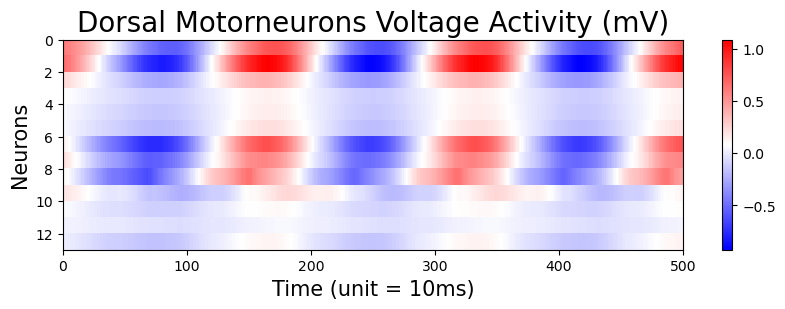

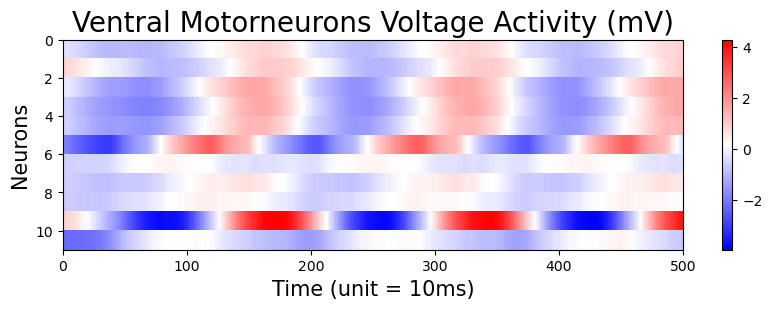

In [241]:
# Test your repaired connectome 

dw.network_sim.test_brain_repair(repaired_synaptic_adj_matrix) 

# If successfully repaired, function will output 
# 1) Motorneurons activity 
# 2) Simulated body movement video with repaired brain